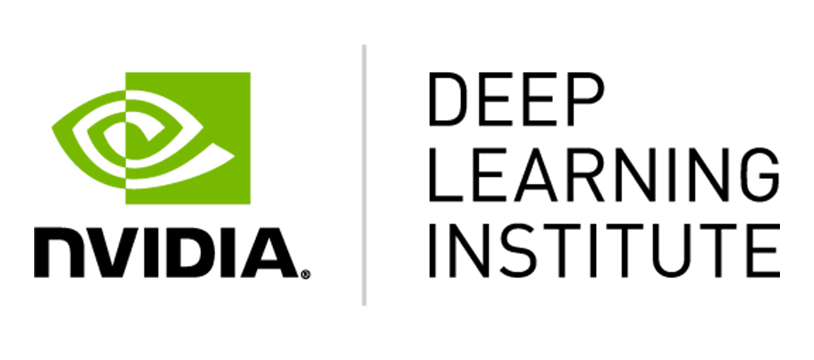

# 4. Distributed Training Optimization

In this notebook, we will learn how to quantify the [NeMo](https://github.com/NVIDIA/NeMoM) GPT pretraining performance and see optimization techniques such as Mixed Precision, Gradient Accumulation and Activation Checkpointing.

## The goals

The goals of this notebook are to:
* Optimize multi-node training of NeMo Framework scripts using Automatic Mixed Precision and Activation Checkpointing
* Understand how to compute training performance


**[4.1 Mixed Precision Training](#4.1-Mixed-Precision-Training)<br>**
**[4.2 Activation Checkpointing](#4.2-Activation-Checkpointing)<br>**
**[4.3 Gradient Accumulation](#4.3-Gradient-Accumulation)<br>**
**[4.4 The Training Performance](#4.4-The-Training-Performance)<br>**
&nbsp;&nbsp;&nbsp;&nbsp;[4.4.1 Compute the Number of Parameters of Transformer Model](#4.4.1-Compute-the-Number-of-Parameters-of-Transformer-Model)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[4.4.2 Exercise: Compute the Number of Parameters For Our Model](#442-exercise-compute-the-number-of-parameters-for-our-model)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[4.4.3 Compute the Theoretical Peak FLOP per second per GPU](#443-compute-the-theoretical-peak-flop-per-second-per-gpu)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[4.4.4 Estimate the Training Duration / Epoch](#444-estimate-the-training-duration--epoch)<br>

### Cancel Previous Running/Pending Jobs

Before moving on, check that no jobs are still running or waiting on the SLURM queue. Let's check the SLURM jobs queue by executing the following cell:

In [ ]:
# Check the SLURM jobs queue
!squeue

             JOBID PARTITION     NAME     USER ST       TIME  NODES NODELIST(REASON)


If there are still jobs running or pending, execute the following cell to cancel all the admin user's jobs with the `scancel` command.

In [ ]:
# Cancel admin user jobs
!scancel -u $USER

# Check again the SLURM jobs queue (should be either empty, or the status TS column should be CG)
!squeue

             JOBID PARTITION     NAME     USER ST       TIME  NODES NODELIST(REASON)


---
# 4.1 Mixed Precision Training

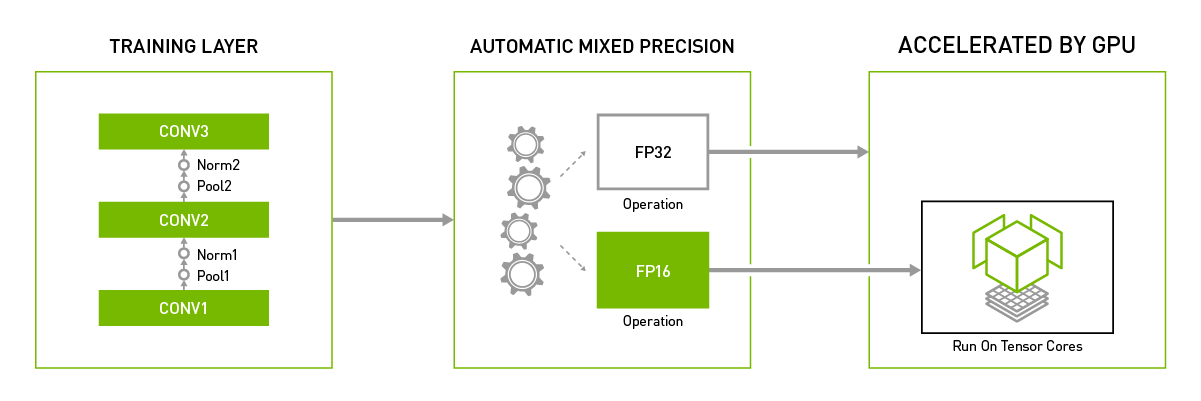

**Automatic Mixed Precision (AMP)** allows using different numerical precisions when running mathematical operations. It performs some operations in half-precision format reducing the memory required while keeping single-precision in critical parts of the network.

Training with Automatic Mixed Precision takes advantage of the hardware acceleration provided by Tensor Cores available in NVIDIA GPUs starting from Volta architecture (Volta, Turing, Ampere, Hopper, and future architectures). To learn more about training with AMP, refer to the [Mixed precision training documentation](https://docs.nvidia.com/deeplearning/performance/mixed-precision-training/index.html).


In the previous notebook, Mixed Precision training was not enabled for the baseline run.  We can confirm that by examining the `HPARAMS` (hyperparameters) tab in TensorBoard.

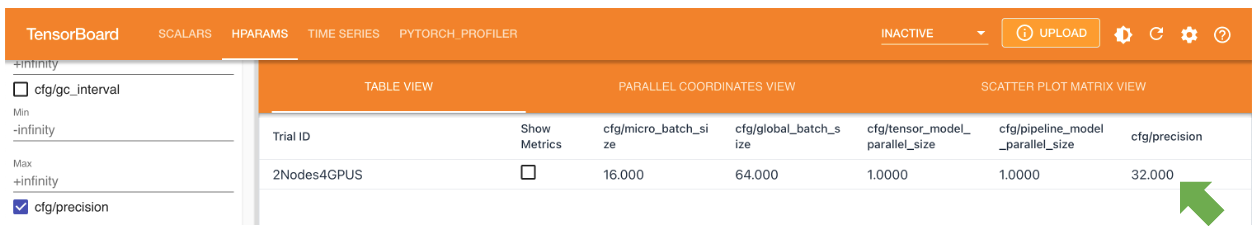
We can speed up the operations by enabling Automatic Mixed Precision with FP16.

To run NeMo GPT pretraining in Mixed Precision, simply update the argument `trainer.precision=16` in the `TRAINER_ARGS`.

In [ ]:
%%writefile /dli/code/pretrain_gpt_2Node4GPU_increase_MBS_fp16.sh
#!/bin/bash
#SBATCH --job-name=dli_2nodes
#SBATCH --nodes=2
#SBATCH --ntasks-per-node=2
#SBATCH --cpus-per-task=32 ### Number of threads per task (OMP threads)
#SBATCH -o /dli/nemo/logs/%j.out
#SBATCH -e /dli/nemo/logs/%j.err

set -x -e

export OMP_NUM_THREADS=$SLURM_CPUS_PER_TASK

# Distributed training args
NNODES=2
GPUS_PER_NODE=2
TP_SIZE=1
PP_SIZE=1

# Distributed training
MICRO_BATCH_SIZE=16
GLOBAL_BATCH_SIZE=64

# Model architecture
NLAYERS=12
NHIDDEN=768
NHEADS=32
SEQ_LEN=1024

# Data Paths
VOCAB_FILE=/dli/data/GPT-2_assets/gpt2-vocab.json
MERGE_FILE=/dli/data/GPT-2_assets/gpt2-merges.txt
DATA_PATH=[1.0,/dli/data/GPT-2_assets/my-gpt2_text_document]

OUTPUT_PATH=/dli/nemo
LOGS_PATH=/dli/nemo/logs
NAME="2Nodes4GPUS_increase_MBS_fp16"

OPTIMIZER_ARGS=" \
            model.optim.name=fused_adam \
            model.optim.betas=[0.9,0.95] \
            model.optim.lr=6e-5 \
            model.optim.sched.min_lr=6e-6 \
            model.optim.sched.name=CosineAnnealing \
            +model.optim.sched.max_steps=800 \
            model.optim.sched.warmup_steps=80 \
            model.optim.weight_decay=1e-1 \
        "

TRAINER_ARGS=" \
            trainer.gradient_clip_val=1.0 \
            trainer.precision=16 \
            trainer.devices=$GPUS_PER_NODE \
            trainer.num_nodes=$NNODES \
            trainer.max_steps=100 \
            trainer.enable_model_summary=true \
            trainer.log_every_n_steps=10 \
            trainer.val_check_interval=20 \
            trainer.limit_val_batches=10 \
            +trainer.use_profiler=true \
        "

GPT_ARGS=" \
            model.num_layers=$NLAYERS \
            model.hidden_size=$NHIDDEN \
            model.num_attention_heads=$NHEADS \
            model.encoder_seq_length=$SEQ_LEN \
            model.data.seq_length=$SEQ_LEN \
            model.max_position_embeddings=$SEQ_LEN \
            model.micro_batch_size=$MICRO_BATCH_SIZE \
            model.global_batch_size=$GLOBAL_BATCH_SIZE \
            model.tokenizer.vocab_file=$VOCAB_FILE \
            model.tokenizer.merge_file=$MERGE_FILE \
            model.init_method_std=0.006 \
            $OPTIMIZER_ARGS \
        "

OUTPUT_ARGS=" \
            exp_manager.explicit_log_dir=$OUTPUT_PATH/$NAME \
            exp_manager.resume_if_exists=false \
            exp_manager.name=$NAME \
        "

PARALLEL_ARGS=" \
            model.tensor_model_parallel_size=$TP_SIZE \
            model.pipeline_model_parallel_size=$PP_SIZE \
        "

export CMD=" \
            python /dli/code/NeMo/examples/nlp/language_modeling/megatron_gpt_pretraining.py \
            --config-path=/dli/code/NeMo/examples/nlp/language_modeling/conf/ \
            --config-name=megatron_gpt_config.yaml \
            $TRAINER_ARGS \
            $PARALLEL_ARGS \
            $GPT_ARGS \
            $OUTPUT_ARGS \
            model.data.data_prefix=$DATA_PATH \
            model.data.data_impl=mmap \
            model.data.splits_string=\"949,50,1\" \
        "

clear; srun --jobid $SLURM_JOBID bash -c 'NCCL_DEBUG=INFO $CMD' 2>&1 | tee -a $LOGS_PATH/$NAME.txt

Overwriting /dli/code/pretrain_gpt_2Node4GPU_increase_MBS_fp16.sh


Now, let's submit the previous sbatch script [pretrain_gpt_2Node4GPU_increase_MBS_fp16.sh](./code/pretrain_gpt_2Node4GPU_increase_MBS_fp16.sh) and check the SLURM queue using the `squeue` command.

In [ ]:
# submit the 2 node job
!sbatch /dli/code/pretrain_gpt_2Node4GPU_increase_MBS_fp16.sh

# Check the SLURM queue
!squeue

Submitted batch job 15
             JOBID PARTITION     NAME     USER ST       TIME  NODES NODELIST(REASON)
                15  slurmpar dli_2nod     root PD       0:00      2 (None)


To understand the performance of the NeMo GPT3 pretraining, we can check the generated logs during execution.

Let's first look at the generated [logs](./nemo/logs/2Nodes4GPUS_increase_MBS_fp16.txt) and check the world size of our executed run. We should see this:

```
trainer:
...
    precision: 16
...
Initializing distributed: GLOBAL_RANK: 0, MEMBER: 1/4
Initializing distributed: GLOBAL_RANK: 1, MEMBER: 2/4
...
Initializing distributed: GLOBAL_RANK: 2, MEMBER: 3/4
Initializing distributed: GLOBAL_RANK: 3, MEMBER: 4/4
...

```

Notice that we are running in fp16 mode.

After a few seconds, let's check the training performance and discuss that with the instructor.

In [ ]:
!sleep 60
!grep Epoch /dli/nemo/logs/2Nodes4GPUS_increase_MBS_fp16.txt | tail -2

Epoch 0, global step 20: 'val_loss' reached 10.68408 (best 10.68408), saving model to '/dli/nemo/2Nodes4GPUS_increase_MBS_fp16/checkpoints/megatron_gpt--val_loss=10.68-step=20-consumed_samples=1216.0.ckpt' as top 10
Epoch 0:  22%|██▏       | 33/150 [00:34<02:02,  1.05s/it, loss=10.8, v_num=, reduced_train_loss=10.60, global_step=21.00, consumed_samples=1344.0, val_loss=10.70]


### Pytorch Profiler with Tensorboard

The profiling is available on the Tensorboard link at the `PYTORCH_PROFILER` tab for the previous run. In case you already closed the Tensorboard page, you can re-generate the link by executing the next cell. Click the link to open Tensorboard and then go to the `PYTORCH_PROFILER` tab.

In [ ]:
%%js
const href = window.location.hostname +'/tensorboard/';
let a = document.createElement('a');
let link = document.createTextNode('Open Tensorboard!');
a.appendChild(link);
a.href = "http://" + href;
a.style.color = "navy"
a.target = "_blank"
element.append(a);

<IPython.core.display.Javascript object>

Looking at the `2Nodes4GPUS_increase_MBS_fp16` results, we see that the GPU utilization is reduced.

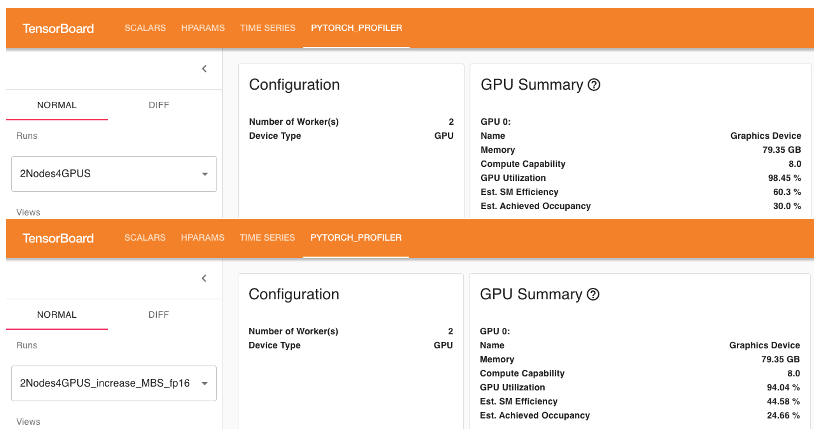

From the GPU Kernel view, we can see that when enabling Mixed precision, 17.2% of GPU operations are accelerated with TensorCores.

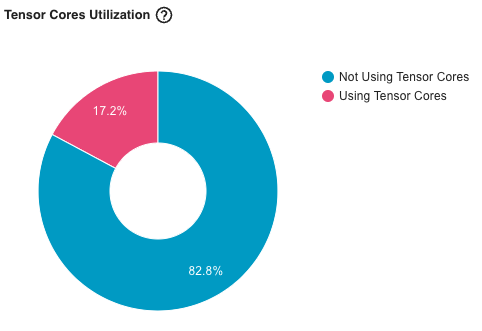


### How about the memory?
We can see that the memory consumption decreased with a peak of \~45G (~73G in the baseline). This is because half-precision floating point format (FP16) uses 16 bits, compared to 32 bits for single precision (FP32). Lowering the required memory enables training larger models or training with larger mini-batches.

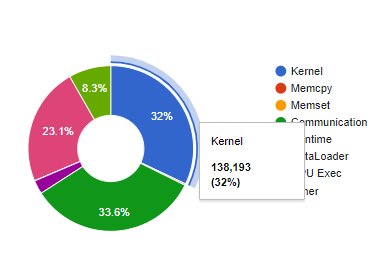


Great! Before moving on, let's release some disk space by deleting the unnecessary checkpoints generated by the previous execution.

In [ ]:
# Clean the checkpoints
!rm -rf /dli/nemo/2Nodes4GPUS_increase_MBS_fp16/checkpoints/

---
# 4.2 Activation Checkpointing


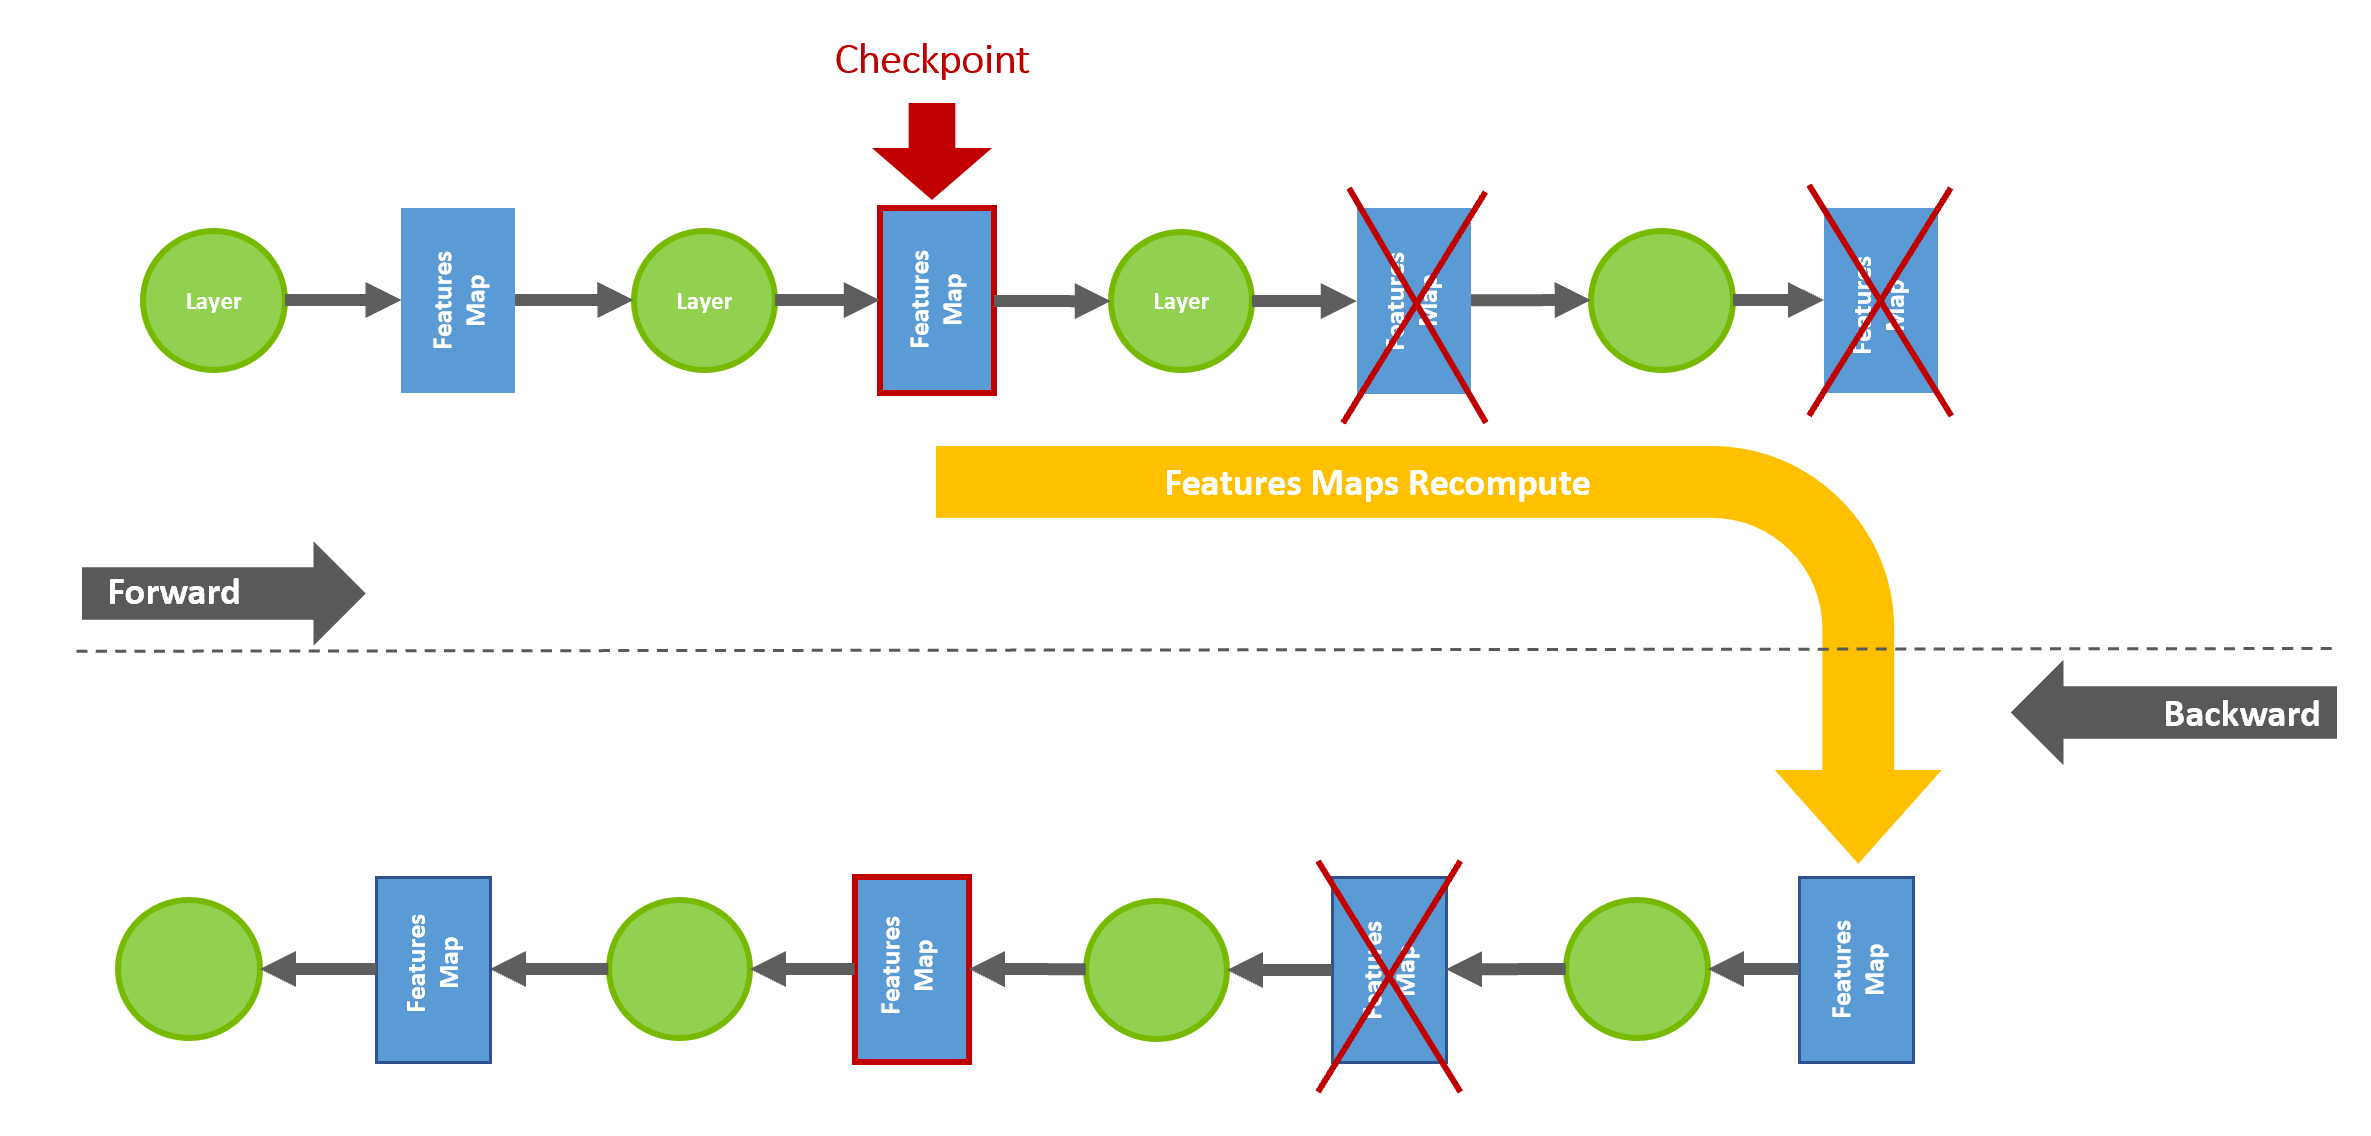

Activation Checkpointing is another technique allowing us to save memory during the training with the cost of additional re-compute. In the vanilla forward and backward pass, all feature maps are computed during the forward pass and stored for the backward step. In the activation checkpointing strategy, only some intermediate results are stored (called checkpoints) during the forward pass. Those checkpoints will be used at the backwards pass to recompute further feature maps when needed. There are several implementations of checkpointing, including manual checkpoints provided by the user or automatic selection.

NeMo Framework supports two activation checkpointing methods: uniform and block.

- Uniform: Uniformly divides the layers into groups and stores the input activations of each group in memory.
- Block: Checkpoints the input activations of a set number of individual Transformer layers per pipeline stage.

To run NeMo GPT pretraining with Activation Checkpointing, simply set the argument `model.activations_checkpoint_method` to `uniform` or `block`, `model.activations_checkpoint_granularity` to `full` or `selective`, and update `model.activations_checkpoint_num_layers` (usually it's sufficient to set it to 1) in `GPT_ARGS`.


In [ ]:
%%writefile /dli/code/pretrain_gpt_2Node4GPU_increase_MBS_fp16_activation_checkpointing.sh
#!/bin/bash
#SBATCH --job-name=dli_2nodes
#SBATCH --nodes=2
#SBATCH --ntasks-per-node=2
#SBATCH --cpus-per-task=32 ### Number of threads per task (OMP threads)
#SBATCH -o /dli/nemo/logs/%j.out
#SBATCH -e /dli/nemo/logs/%j.err

set -x -e

export OMP_NUM_THREADS=$SLURM_CPUS_PER_TASK

# Distributed training args
NNODES=2
GPUS_PER_NODE=2
TP_SIZE=1
PP_SIZE=1

# Distributed training
MICRO_BATCH_SIZE=16
GLOBAL_BATCH_SIZE=64

# Model architecture
NLAYERS=12
NHIDDEN=768
NHEADS=32
SEQ_LEN=1024

# Data Paths
VOCAB_FILE=/dli/data/GPT-2_assets/gpt2-vocab.json
MERGE_FILE=/dli/data/GPT-2_assets/gpt2-merges.txt
DATA_PATH=[1.0,/dli/data/GPT-2_assets/my-gpt2_text_document]

OUTPUT_PATH=/dli/nemo
LOGS_PATH=/dli/nemo/logs
NAME="2Nodes4GPUS_increase_MBS_fp16_activation_checkpointing"


OPTIMIZER_ARGS=" \
            model.optim.name=fused_adam \
            model.optim.betas=[0.9,0.95] \
            model.optim.lr=6e-5 \
            model.optim.sched.min_lr=6e-6 \
            model.optim.sched.name=CosineAnnealing \
            +model.optim.sched.max_steps=800 \
            model.optim.sched.warmup_steps=80 \
            model.optim.weight_decay=1e-1 \
        "

TRAINER_ARGS=" \
            trainer.gradient_clip_val=1.0 \
            trainer.precision=16 \
            trainer.devices=$GPUS_PER_NODE \
            trainer.num_nodes=$NNODES \
            trainer.max_steps=100 \
            trainer.enable_model_summary=true \
            trainer.log_every_n_steps=10 \
            trainer.val_check_interval=20 \
            trainer.limit_val_batches=10 \
            +trainer.use_profiler=true \
        "

GPT_ARGS=" \
            model.num_layers=$NLAYERS \
            model.hidden_size=$NHIDDEN \
            model.num_attention_heads=$NHEADS \
            model.encoder_seq_length=$SEQ_LEN \
            model.data.seq_length=$SEQ_LEN \
            model.max_position_embeddings=$SEQ_LEN \
            model.micro_batch_size=$MICRO_BATCH_SIZE \
            model.global_batch_size=$GLOBAL_BATCH_SIZE \
            model.tokenizer.vocab_file=$VOCAB_FILE \
            model.tokenizer.merge_file=$MERGE_FILE \
            model.init_method_std=0.006 \
            model.activations_checkpoint_method=uniform \
            model.activations_checkpoint_granularity=full \
            model.activations_checkpoint_num_layers=1 \
            $OPTIMIZER_ARGS \
        "

OUTPUT_ARGS=" \
            exp_manager.explicit_log_dir=$OUTPUT_PATH/$NAME \
            exp_manager.resume_if_exists=false \
            exp_manager.name=$NAME \
        "

PARALLEL_ARGS=" \
            model.tensor_model_parallel_size=$TP_SIZE \
            model.pipeline_model_parallel_size=$PP_SIZE \
        "

export CMD=" \
            python /dli/code/NeMo/examples/nlp/language_modeling/megatron_gpt_pretraining.py \
            --config-path=/dli/code/NeMo/examples/nlp/language_modeling/conf/ \
            --config-name=megatron_gpt_config.yaml \
            $TRAINER_ARGS \
            $PARALLEL_ARGS \
            $GPT_ARGS \
            $OUTPUT_ARGS \
            model.data.data_prefix=$DATA_PATH \
            model.data.data_impl=mmap \
            model.data.splits_string=\"949,50,1\" \
        "

clear; srun --jobid $SLURM_JOBID bash -c 'NCCL_DEBUG=INFO $CMD' 2>&1 | tee -a $LOGS_PATH/$NAME.txt

Writing /dli/code/pretrain_gpt_2Node4GPU_increase_MBS_fp16_activation_checkpointing.sh


Now, let's submit the previous sbatch script [pretrain_gpt_2Node4GPU_increase_MBS_fp16_activation_checkpointing.sh](./code/pretrain_gpt_2Node4GPU_increase_MBS_fp16_activation_checkpoiting.sh) and check the SLURM queue using the `squeue` command.

In [ ]:
# Submit the 2 node job
!sbatch /dli/code/pretrain_gpt_2Node4GPU_increase_MBS_fp16_activation_checkpointing.sh

# Check the SLURM queue
!squeue

Submitted batch job 16
             JOBID PARTITION     NAME     USER ST       TIME  NODES NODELIST(REASON)
                16  slurmpar dli_2nod     root  R       0:00      2 slurmnode[1-2]


To understand the performance of the NeMo GPT3 pretraining, we can check the generated [logs](./nemo/logs/2Nodes4GPUS_increase_MBS_fp16_activation_checkpoiting.txt) and discuss them with the instructor.

In [ ]:
!sleep 60
!grep Epoch /dli/nemo/logs/2Nodes4GPUS_increase_MBS_fp16_activation_checkpointing.txt| tail -2

Epoch 0:  20%|██        | 30/150 [00:32<02:10,  1.09s/it, loss=10.8, v_num=, reduced_train_loss=10.80, global_step=19.00, consumed_samples=1216.0, val_loss=10.70]
Epoch 0, global step 20: 'val_loss' reached 10.68408 (best 10.68408), saving model to '/dli/nemo/2Nodes4GPUS_increase_MBS_fp16_activation_checkpointing/checkpoints/megatron_gpt--val_loss=10.68-step=20-consumed_samples=1216.0.ckpt' as top 10


### What about the memory?

The profiling is available on the Tensorboard link at the `PYTORCH_PROFILER` tab. When using activation checkpointing, we can see that for `2Nodes4GPUS_increase_MBS_fp16_activation_checkpointing` the memory consumption for a single GPU is reduced considerably to a peak of ~10G. This is since some activations are not stored and recomputed when necessary. Also notice the increase in the time for a single training step.


By zooming into the graph, we can trace the Pytorch `CheckpointFunctions`.

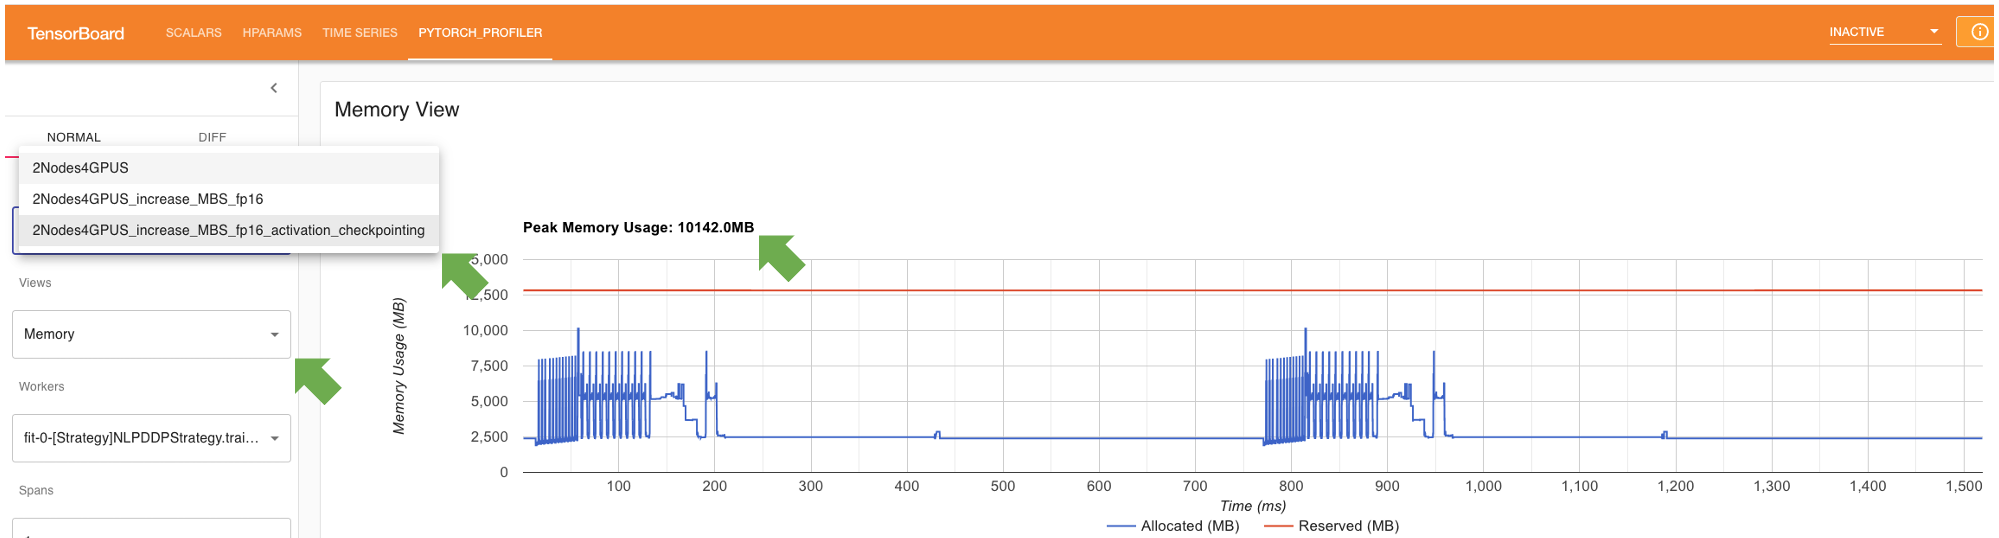

Great! Before moving on, let's release some disk space by deleting the unnecessary checkpoints generated by the previous execution.

In [ ]:
# Clean the checkpoints
!rm -rf /dli/nemo/2Nodes4GPUS_increase_MBS_fp16_activation_checkpointing/checkpoints/

---
# 4.3 Gradient Accumulation


Another way of increasing the batch size is to use gradient accumulation. Instead of splitting the data across workers as in Distributed Data Parallel, in the Gradient Accumulation technique the same worker processes several batches and accumulates the gradients before updating the model parameters.

[NVIDIA APEX Library](https://github.com/NVIDIA/apex) provides an optimized implementation when using Gradient Accumulation with Automatic Mixed precision. This implementation removes unnecessary double precision copies of the gradient by accumulating it in low precision first before going back to double precision. NeMo Framework uses the APEX implementation.  


To run NeMo GPT pretraining with Gradient Accumulation, simply increase the global batch size while maintaining the micro batch size the same.  

In [ ]:
%%writefile /dli/code/pretrain_gpt_2Node4GPU_increase_MBS_fp16_activation_checkpointing_gradient_accumulation.sh
#!/bin/bash
#SBATCH --job-name=dli_2nodes
#SBATCH --nodes=2
#SBATCH --ntasks-per-node=2
#SBATCH --cpus-per-task=32 ### Number of threads per task (OMP threads)
#SBATCH -o /dli/nemo/logs/%j.out
#SBATCH -e /dli/nemo/logs/%j.err

set -x -e

export OMP_NUM_THREADS=$SLURM_CPUS_PER_TASK

# Distributed training args
NNODES=2
GPUS_PER_NODE=2
TP_SIZE=1
PP_SIZE=1

# Distributed training
MICRO_BATCH_SIZE=16
GLOBAL_BATCH_SIZE=256

# Model architecture
NLAYERS=12
NHIDDEN=768
NHEADS=32
SEQ_LEN=1024

# Data Paths
VOCAB_FILE=/dli/data/GPT-2_assets/gpt2-vocab.json
MERGE_FILE=/dli/data/GPT-2_assets/gpt2-merges.txt
DATA_PATH=[1.0,/dli/data/GPT-2_assets/my-gpt2_text_document]

OUTPUT_PATH=/dli/nemo
LOGS_PATH=/dli/nemo/logs
NAME="2Nodes4GPUS_increase_MBS_fp16_activation_checkpointing_gradient_accumulation"


OPTIMIZER_ARGS=" \
            model.optim.name=fused_adam \
            model.optim.betas=[0.9,0.95] \
            model.optim.lr=6e-5 \
            model.optim.sched.min_lr=6e-6 \
            model.optim.sched.name=CosineAnnealing \
            +model.optim.sched.max_steps=800 \
            model.optim.sched.warmup_steps=80 \
            model.optim.weight_decay=1e-1 \
        "

TRAINER_ARGS=" \
            trainer.gradient_clip_val=1.0 \
            trainer.precision=16 \
            trainer.devices=$GPUS_PER_NODE \
            trainer.num_nodes=$NNODES \
            trainer.max_steps=100 \
            trainer.enable_model_summary=true \
            trainer.log_every_n_steps=10 \
            trainer.val_check_interval=20 \
            trainer.limit_val_batches=10 \
            +trainer.use_profiler=true \
        "

GPT_ARGS=" \
            model.num_layers=$NLAYERS \
            model.hidden_size=$NHIDDEN \
            model.num_attention_heads=$NHEADS \
            model.encoder_seq_length=$SEQ_LEN \
            model.data.seq_length=$SEQ_LEN \
            model.max_position_embeddings=$SEQ_LEN \
            model.micro_batch_size=$MICRO_BATCH_SIZE \
            model.global_batch_size=$GLOBAL_BATCH_SIZE \
            model.tokenizer.vocab_file=$VOCAB_FILE \
            model.tokenizer.merge_file=$MERGE_FILE \
            model.init_method_std=0.006 \
            model.activations_checkpoint_method=uniform \
            model.activations_checkpoint_granularity=full \
            model.activations_checkpoint_num_layers=1 \
            $OPTIMIZER_ARGS \
        "

OUTPUT_ARGS=" \
            exp_manager.explicit_log_dir=$OUTPUT_PATH/$NAME \
            exp_manager.resume_if_exists=false \
            exp_manager.name=$NAME \
        "

PARALLEL_ARGS=" \
            model.tensor_model_parallel_size=$TP_SIZE \
            model.pipeline_model_parallel_size=$PP_SIZE \
        "

export CMD=" \
            python /dli/code/NeMo/examples/nlp/language_modeling/megatron_gpt_pretraining.py \
            --config-path=/dli/code/NeMo/examples/nlp/language_modeling/conf/ \
            --config-name=megatron_gpt_config.yaml \
            $TRAINER_ARGS \
            $PARALLEL_ARGS \
            $GPT_ARGS \
            $OUTPUT_ARGS \
            model.data.data_prefix=$DATA_PATH \
            model.data.data_impl=mmap \
            model.data.splits_string=\"949,50,1\" \
        "

clear; srun --jobid $SLURM_JOBID bash -c 'NCCL_DEBUG=INFO $CMD' 2>&1 | tee -a $LOGS_PATH/$NAME.txt

Writing /dli/code/pretrain_gpt_2Node4GPU_increase_MBS_fp16_activation_checkpointing_gradient_accumulation.sh


Now, let's submit the previous sbatch script [pretrain_gpt_2Node4GPU_increase_MBS_fp16_activation_checkpointing_gradient_accumulation.sh](./code/pretrain_gpt_2Node4GPU_increase_MBS_fp16_activation_checkpointing_gradient_accumulation.sh) and check the SLURM queue using the `squeue` command.

In [ ]:
# Submit the 2 node job
!sbatch /dli/code/pretrain_gpt_2Node4GPU_increase_MBS_fp16_activation_checkpointing_gradient_accumulation.sh

# Check the SLURM queue
!squeue

Submitted batch job 17
             JOBID PARTITION     NAME     USER ST       TIME  NODES NODELIST(REASON)
                17  slurmpar dli_2nod     root PD       0:00      2 (None)
                16  slurmpar dli_2nod     root  R       2:14      2 slurmnode[1-2]


To understand the performance of the NeMo GPT3 pretraining, we can check the generated [logs](./nemo/logs/log_2Nodes4GPUS_increase_MBS_fp16_activation_checkpointing_gradient_accumulation.txt) and discuss them with the instructor.

Let's compare the number of micro-batches per GPU when enabling or disabling Gradient Accumulation. To do so, let’s compare to the previous runs without Gradient Accumulation.

In [ ]:
!sleep 60

print("Without gradient accumulation:")
!grep constant /dli/nemo/logs/2Nodes4GPUS_increase_MBS_fp16_activation_checkpointing.txt

print()

print("With 4x gradient accumulation:")
!grep constant /dli/nemo/logs/2Nodes4GPUS_increase_MBS_fp16_activation_checkpointing_gradient_accumulation.txt

Without gradient accumulation:
          constant_steps: 50000
26-07-28 02:31:51 - PID:11284 - rank:(0, 0, 0, 0) - microbatches.py:39 - INFO - setting number of micro-batches to constant 1
    constant_steps: 50000

With 4x gradient accumulation:
          constant_steps: 50000
26-07-28 02:34:25 - PID:13231 - rank:(0, 0, 0, 0) - microbatches.py:39 - INFO - setting number of micro-batches to constant 4
    constant_steps: 50000


Let's examine the training performance and the number of consumed samples with Gradient Accumulation:

In [ ]:
!grep Epoch /dli/nemo/logs/2Nodes4GPUS_increase_MBS_fp16_activation_checkpointing_gradient_accumulation.txt | tail -2

Epoch 0:   0%|          | 0/150 [00:00<?, ?it/s] [NeMo I 2026-07-28 02:34:53 indexed_dataset:454]     reading sizes...


### How about the memory?

The profiling is available in Tensorboard link at the `PYTORCH_PROFILER` tab under the run `2Nodes4GPUS_increase_MBS_fp16_activation_checkpointing_gradient_accumulation`.

We can see the 4 gradient accumulations stages per step on the memory tracing.

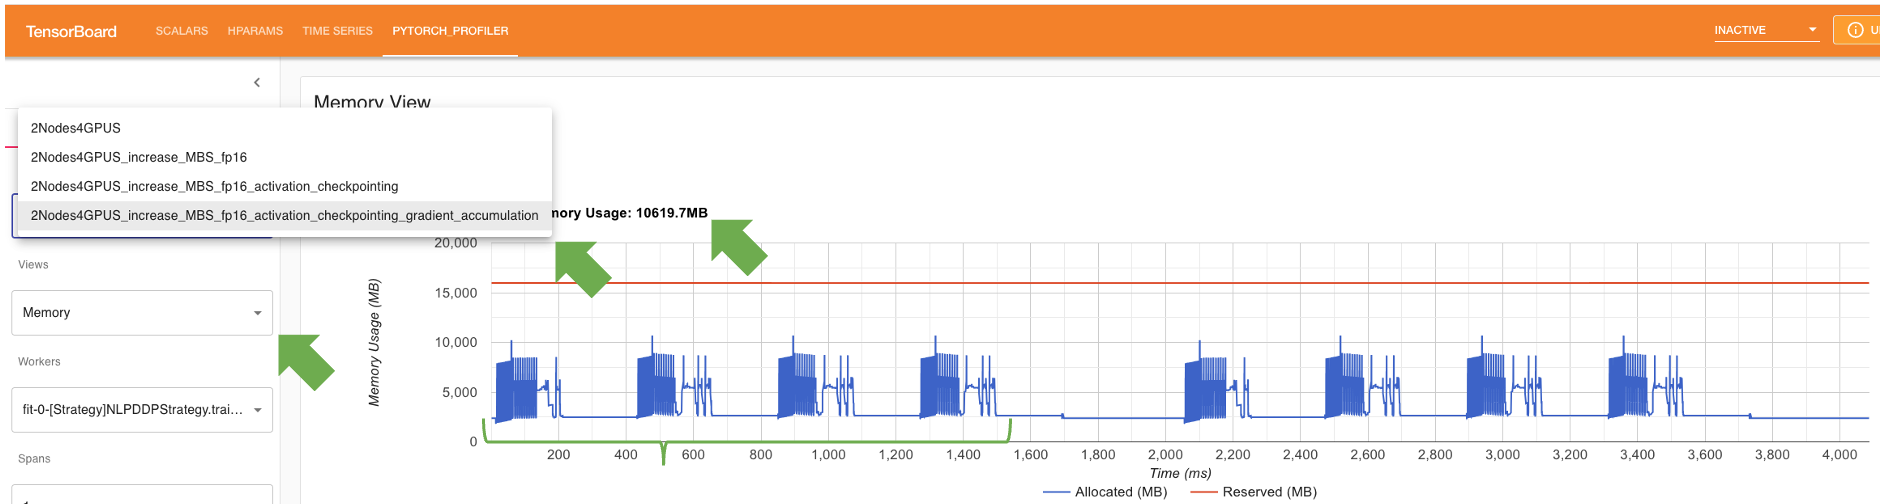


Great! Before moving on, let's release some disk space by deleting the unnecessary checkpoints generated by the previous execution.

In [ ]:
# Clean the checkpoints
!rm -rf /dli/nemo/2Nodes4GPUS_increase_MBS_fp16_activation_checkpointing_gradient_accumulation/checkpoints/

---
# 4.4 The Training Performance

In order to train large Neural Networks in a reasonable time, scaling the infrastructure is unavoidable.
Let's first compute the number of parameters of our transformer models and estimate its training according to the hardware infrastructure and the experimentally observed training throughput.


## 4.4.1 Compute the Number of Parameters of Transformer Model

The number of parameters for a Transformers model is computed as:
$P = 12 l h^2 (1 + \frac{13}{12h} + \frac{V+s}{12lh})$ where:
- $l$ = Number of Layers
- $h$ = Hidden Size
- $V$ = Vocabulary Size
- $s$ = Sequence Length


In [ ]:
# Number of parameters of the Transformers model
def calculate_number_parameters(l,h,s,V):
    # Compute the number of parameters of the model
    P=12*l*h*h *(1+ (13/(12*h)) + ((V+s)/(12*l*h)))
    print("The number of parameters for the GPT architecture is: {} \n".format(int(P)))
    return P

As an example, let's compute the number of parameters of the transformer model having 40 layers, a hidden size of 6144, vocabulary size of 50257 and sequence length of 1024. This model should be approximately 18 billion parameters.

In [ ]:
# Set the model architecture parameters
l=40
h=6144
s=1048
V=50257

P=calculate_number_parameters(l,h,s,V)

The number of parameters for the GPT architecture is: 18437806080 



## 4.4.2 Exercise: Compute the Number of Parameters For Our Model

Compute the number of parameters of the model we have been experimenting with in previous notebooks.
Have a look at the model architecture arguments in any NeMo GPT pretraining scripts from previous notebooks.

The vocabulary size is not specified explicitly in scripts and is also **50257** for NeMo GPT.

If you get stuck, you can look at the [solution](solutions/ex4.1.2.ipynb).

In [ ]:
# Set our model architecture parameters
l=12
h=768
s=1024
V=50257

calculate_number_parameters(l,h,s,V)

The number of parameters for the GPT architecture is: 124438272 



124438272.0

## 4.4.3 Compute the Theoretical Peak FLOP per second per GPU

As detailed in the paper [Efficient Large-Scale Language Model Training on GPU Clusters Using Megatron-LM](https://arxiv.org/pdf/2104.04473.pdf), the majority of floating-point operations in the model are performed in the matrix multiplications (GEMMs). If we consider only these GEMMs operations, the number of FLOPs per iteration is $F = 96 B s l h^2 (1 + \frac{s}{6h} + \frac{V}{16lh})$ where $B$ is the batch size.

And, in case we have an estimate of the time spent per iteration `time_per_iteration_second`, it is possible then to compute the theoretical peak FLOP per second and per GPUs and estimate the GPU usage by comparing.

The following table shows the training performance of several GPT model sizes (from 1.7B to 1 trillion) pretrained on a SuperPOD cluster with A100 GPUs.
<img src="https://github.com/NVIDIA/Megatron-LM/blob/main/images/cases_april2021.png?raw=true"/>


In [ ]:
# Theoretical peak FLOP per second per GPU - with activation checkpointing (2 forwards and 1 backward)
def calculate_theoretical_peak_FLOP_s_GPU(B, s, l, h, number_GPUs, time_per_iteration_second):
    # The number of FLOPs per iteration
    F = 96*B*s* l*h*h *(1 + s/ (6*h) + V/(16*l*h))/1e+12

    #Theoretical peak FLOP per second per GPU
    PF= (F/time_per_iteration_second/number_GPUs)
    print("Theoretical peak FLOP/s/GPU: {}\n".format(PF))

    # Percentage of theoretical peak FLOP/s on a A100 FP16 (change according the hardware)
    GPU_usage= PF/ 312 *100
    print("Percentage of theoretical peak FLOP/s: {}%".format(GPU_usage))

    return PF, GPU_usage

The percentage of theoretical peak FLOP/s in the previous function is based on **A100** hardware capabilities in **FP16/BF16 which is 312**. This needs to be updated according to the corresponding Tensor Core GPU performance specs. To learn more about the Ampere and newer Hopper architecture specifications, follow the following links: [Ampere](https://developer.nvidia.com/blog/nvidia-ampere-architecture-in-depth/), [Hopper](https://www.nvidia.com/en-us/data-center/technologies/hopper-architecture/).


If we consider our previous 18B parameters models pretrained on 16 GPUs with a global batch size of 512, they have a time per iteration of 32.09s.
Let's compute the theoretical peak FLOP per second per GPU and the percentage GPU utilization:

In [ ]:
global_batch_size=512
number_GPUs=16
time_per_iteration_second=32.09

# Considering the 18B parameters model
l=40
h=6144
s=1048
V=50257

PF,GPU_usage=calculate_theoretical_peak_FLOP_s_GPU(global_batch_size, s, l, h, number_GPUs, time_per_iteration_second)

Theoretical peak FLOP/s/GPU: 157.7296879710454

Percentage of theoretical peak FLOP/s: 50.55438717020686%


## 4.4.4 Estimate the Training Duration / Epoch

It is possible to estimate training duration per epoch according to the model, dataset, and hardware size. Training time (in seconds) is approximated with this equation $\approx \frac{8*T*P}{n * PF}$ where:
- $T$ = Number of tokens in the dataset
- $P$ = Numbers of parameters
- $n$ = Number of GPUs
- $PF$ = Achieved teraFLOP/s per GPU

More details are described in the paper [Efficient Large-Scale Language Model Training on GPU Clusters Using Megatron-LM](https://arxiv.org/pdf/2104.04473.pdf).

Let's execute the 2 following cells to estimate the training duration for the 18B parameters models trained on a dataset of $T$=300 billion tokens:

In [ ]:
from termcolor import colored

# Estimate the training time
def estimate_days_needed(T, P, N, PF):
    compute_sec=8*T*P/(N*PF*10e12)
    # Convert compute seconds to days
    to_days=round(compute_sec/(3600*24))
    print("This language model will need {} days per epoch.".format(colored(str(to_days),'blue', attrs=['bold'])))

In [ ]:
# Number of tokens in the dataset
T=300*10e09

estimate_days_needed(T, P, number_GPUs, PF)

This language model will need 203 days per epoch.


The result is 203 days, which is almost **7 months** required to train the 18B model on 16 GPUs (2 nodes) with a dataset of 300B tokens!

In this case, scaling the number of nodes is unavoidable in order to train the model in a reasonable amount of time.

For instance, consider a GPT-3 model with $P$=175 billion parameters trained on a dataset of $T$=300 billion tokens on $n$=1024 A100 GPUs. Using a batch size of 1536, we achieve $F$=140 teraFLOP/s per GPU. Thus, the time required to train this model is **34 days**.


---
<h2 style="color:green;">Congratulations!</h2>

Before moving on, we need to make sure no jobs are still running or waiting in the queue.

In [ ]:
# Check the SLURM jobs queue
!squeue

             JOBID PARTITION     NAME     USER ST       TIME  NODES NODELIST(REASON)


If there are still jobs running or pending, execute the following cell to cancel all the admin user's jobs using the `scancel` command.

In [ ]:
# Cancel admin user jobs
!scancel -u $USER

# Check again the SLURM jobs queue (should be either empty, or the status TS column should be CG)
!squeue

             JOBID PARTITION     NAME     USER ST       TIME  NODES NODELIST(REASON)


In the next lab, we will have an introduction to [NeMo Framework Launcher](https://github.com/NVIDIA/NeMo-Megatron-Launcher), designed to be a simple and easy to use tool for launching NeMo Framework training jobs on CSPs or on-prem clusters. Move on to [05_NeMo_Framework_Launcher.ipynb](05_NeMo_Framework_Launcher.ipynb).